# Mount Drive

In [67]:

from google.colab import drive
drive.mount('/content/drive')
basePath = '/content/drive/MyDrive/MOOCCubeX/Dataset/'
entitiesPath = basePath+'entities'
relationsPath = basePath+'relations'
!ls {basePath}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
course_filtered.csv	   entities
course_final_cleaned.csv   Label_3_and_5_classes.csv
course_limit_Nhom6.csv	   prerequisites
course_merged.csv	   relations
course_proportion.csv	   resource_exercise_course.parquet
Data_cleaned		   resource_video_course.parquet
data_for_Score_Struct.csv  user_course_use_labeling.parquet


In [68]:
import json
import gzip
import bz2
import orjson

def read_jsonl_in_batches(file_path, batch_size=10000, use_orjson=True):
    """
    Đọc file JSON Lines theo từng batch và yield DataFrame.

    Parameters
    ----------
    file_path : str
        Đường dẫn tới file JSONL (có thể nén .gz hoặc .bz2)
    batch_size : int
        Số dòng mỗi batch
    use_orjson : bool
        Sử dụng orjson để tăng tốc (nếu có cài đặt)

    Yields
    ------
    pd.DataFrame
        Batch dữ liệu dưới dạng DataFrame
    """

    # Chọn thư viện parse JSON
    json_loader = orjson.loads if use_orjson else json.loads

    # Chọn method mở file (hỗ trợ file nén)
    if file_path.endswith(".gz"):
        open_func = gzip.open
    elif file_path.endswith(".bz2"):
        open_func = bz2.open
    else:
        open_func = open

    total_lines = 0
    error_lines = 0
    batch = []

    try:
        with open_func(file_path, 'rt', encoding='utf-8') as file:
            for line_num, line in enumerate(file, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json_loader(line)
                    batch.append(obj)
                except Exception as e:
                    error_lines += 1
                    print(f"[Warning] Lỗi parse JSON tại dòng {line_num}: {e}")
                    continue

                if len(batch) >= batch_size:
                    yield pd.DataFrame(batch)
                    total_lines += len(batch)
                    batch = []

            # Batch cuối
            if batch:
                yield pd.DataFrame(batch)
                total_lines += len(batch)

    except FileNotFoundError:
        print(f"[Error] File không tồn tại: {file_path}")
    except Exception as e:
        print(f"[Error] Lỗi khi đọc file: {e}")

    print(f"[Done] Đọc xong {total_lines} dòng hợp lệ, {error_lines} dòng lỗi.")

# Read data

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
# Doc file du lieu course.json
courses_df = pd.concat(read_jsonl_in_batches(entitiesPath+'/course.json'), ignore_index=True)
print(courses_df.shape)
print(courses_df.info())
courses_df.head()

[Done] Đọc xong 3781 dòng hợp lệ, 0 dòng lỗi.
(3781, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3781 entries, 0 to 3780
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             3781 non-null   object
 1   name           3781 non-null   object
 2   field          3781 non-null   object
 3   prerequisites  3779 non-null   object
 4   about          3779 non-null   object
 5   resource       3781 non-null   object
dtypes: object(6)
memory usage: 177.4+ KB
None


,id,name,field,prerequisites,about,resource
0,C_584313,《资治通鉴》导读,"[历史学, 中国语言文学]",,通过老师导读，同学们可深入这一经典文本内部，得以纵览千年历史，提升国学素养，体味人生智慧。,"[{'titles': ['第一课 导论与三家分晋', '导论', '导论'], 'reso..."
1,C_584329,微积分——极限理论与一元函数,"[应用经济学, 数学, 物理学, 理论经济学]",,本课程是理工科的一门数学基础课，系统、全面地介绍了一元函数微积分学。课程既保持了数学的严谨和...,"[{'titles': ['序言', '序言', '序言'], 'resource_id':..."
2,C_584381,新闻摄影,"[艺术学, 新闻传播学]",,掌握基本的摄影技能，了解图片新闻的工作方式，训练对生活的观察和热爱，发展对图像的审美和批评能...,"[{'titles': ['第一章 绪论', '第一讲 引言1', '引言1'], 'res..."
3,C_597208,数据挖掘：理论与算法,[计算机科学与技术],,最有趣的理论+最有用的算法=不得不学的数据科学。,"[{'titles': ['走进数据科学：博大精深，美不胜收', '整装待发', 'Vide..."
4,C_597225,大学计算机,[],,大学计算机课程将以计算思维为导向，以计算机原理、概念为基础，以新技术新方法为牵引，以创新思维...,"[{'titles': ['第1周： 基于计算机的问题求解', '课程介绍', '开篇'],..."


In [71]:
# Kiểm tra giá trị null của từng cột
print(courses_df.isnull().sum())
# Kiểm tra 2 cột dữ liệu dạng mảng là field và resource có bao nhiêu dòng có độ dài = 0
print(f"field:{courses_df[courses_df['field'].apply(lambda x: len(x) == 0)].shape}")
print(f"resource: {courses_df[courses_df['resource'].apply(lambda x: len(x) == 0)].shape}")

id               0
name             0
field            0
prerequisites    2
about            2
resource         0
dtype: int64
field:(3234, 6)
resource: (0, 6)


In [72]:
# Đọc dữ liệu file course-field.json
course_field_df = pd.read_json(relationsPath+'/course-field.json', lines=True)
print(course_field_df.shape)
print(course_field_df.info())
course_field_df.head()

(632, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 632 entries, 0 to 631
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   course_id    632 non-null    int64 
 1   course_name  632 non-null    object
 2   field        632 non-null    object
dtypes: int64(1), object(2)
memory usage: 14.9+ KB
None


,course_id,course_name,field
0,584313,《资治通鉴》导读,"[中国语言文学, 历史学]"
1,681932,“做中学”Java程序设计,[计算机科学与技术]
2,674962,《红楼梦》的空间艺术,[中国语言文学]
3,682709,《纯粹理性批判》导论,[哲学]
4,682635,《统万城》导读,[历史学]


In [73]:
# # Đọc dữ liệu file course_field_filled_slice.parquet
# course_field_filled_df = pd.read_parquet(basePath+'EDA2/relations/course_field_filled_slice.parquet')
# print(course_field_filled_df.shape)
# print(course_field_filled_df.info())
# course_field_filled_df.head()

# Xử Lý Resource

In [74]:
list_resource_df=courses_df[['id','resource']].explode('resource')
# in 1 dong resource ra để xem xét
list_resource_df


,id,resource
0,C_584313,"{'titles': ['第一课 导论与三家分晋', '导论', '导论'], 'resou..."
0,C_584313,"{'titles': ['第一课 导论与三家分晋', '智伯的覆亡', '智伯的覆亡'], ..."
0,C_584313,"{'titles': ['第一课 导论与三家分晋', '智伯悲剧的反思', '智伯的覆亡讨论..."
0,C_584313,"{'titles': ['第一课 导论与三家分晋', None, '第一课 导论与三家分晋-..."
0,C_584313,"{'titles': ['第二课 战国前期的政治', '魏文侯治国', '魏文侯治国'], ..."
...,...,...
3780,C_2329163,"{'titles': ['第四章 红色之旅实践写作', '4.16 求职简历', '4...."
3780,C_2329163,"{'titles': ['第四章 红色之旅实践写作', '4.16 求职简历', '求职..."
3780,C_2329163,"{'titles': ['第四章 红色之旅实践写作', '4.17 实践—演讲稿', '..."
3780,C_2329163,"{'titles': ['第四章 红色之旅实践写作', '4.18 延安保育院观后感',..."


In [75]:
import pandas as pd

resource_df = courses_df[['id', 'resource']].explode('resource')

# Hàm tiện ích để lấy titles_chapter và title_xxx
def extract_titles(titles):
    if not titles:
        return None, None
    titles_chapter = titles[0] if len(titles) > 0 else None

    title_sub = None
    if len(titles) > 1 and titles[1]:
        title_sub = titles[1]
    elif len(titles) > 2 and titles[2]:
        title_sub = titles[2]

    return titles_chapter, title_sub

# Tách video
resource_df_video = (
    resource_df[
        resource_df['resource'].apply(lambda x: isinstance(x, dict) and x.get('resource_id','').startswith('V_'))
    ].assign(
        titles_chapter=lambda df: df['resource'].apply(lambda x: extract_titles(x.get('titles'))[0]),
        title_video=lambda df: df['resource'].apply(lambda x: extract_titles(x.get('titles'))[1]),
        chapter=lambda df: df['resource'].apply(lambda x: x.get('chapter')),
        video_id=lambda df: df['resource'].apply(lambda x: x.get('resource_id'))
    )
)

# Tách exercise
resource_df_exercise = (
    resource_df[
        resource_df['resource'].apply(lambda x: isinstance(x, dict) and x.get('resource_id','').startswith('Ex_'))
    ].assign(
        titles_chapter=lambda df: df['resource'].apply(lambda x: extract_titles(x.get('titles'))[0]),
        title_exercise=lambda df: df['resource'].apply(lambda x: extract_titles(x.get('titles'))[1]),
        chapter=lambda df: df['resource'].apply(lambda x: x.get('chapter')),
        ex_id=lambda df: df['resource'].apply(lambda x: x.get('resource_id'))
    )
)

# Gom theo id
agg_func = lambda x: [item for item in x if item is not None]

resource_df_video = (
    resource_df_video.groupby('id').agg({
        'titles_chapter': agg_func,
        'title_video': agg_func,
        'chapter': agg_func,
        'video_id': agg_func
    }).reset_index()
)

resource_df_exercise = (
    resource_df_exercise.groupby('id').agg({
        'titles_chapter': agg_func,
        'title_exercise': agg_func,
        'chapter': agg_func,
        'ex_id': agg_func
    }).reset_index()
)

# Thêm cột đếm
resource_df_video['video_counts'] = resource_df_video['video_id'].apply(len)
resource_df_exercise['ex_counts'] = resource_df_exercise['ex_id'].apply(len)

# Preview
resource_df_video.head()


,id,titles_chapter,title_video,chapter,video_id,video_counts
0,C_1017355,"[Unit 1 Introduction to Chinese Medicine, Unit...","[1.1 Brief History of Chinese Medicine, 1.2\t...","[0, 0.1, 1, 1.1, 1.1.1, 1.2.1, 2, 2.1, 3, 3.1,...","[V_1617852, V_1617854, V_1736570, V_1736573, V...",19
1,C_1017419,"[课程简介, 第一讲 智慧政府：智慧金融, 第一讲 智慧政府：智慧金融, 第二讲 智慧政府：...","[课程宣传视频, 一、什么是智慧金融, 二、政府如何建立完善智慧金融征信体系？, 一、智慧政...","[1.2, 2.1, 2.2, 3.1, 3.2, 4.1, 4.2, 5.1, 5.2, ...","[V_1618247, V_1618249, V_1618250, V_1618252, V...",17
2,C_1025064,"[第1章 思想政治教育与思想政治教育学述要, 第1章 思想政治教育与思想政治教育学述...","[1.1 思想政治教育的概念, 1.2思想政治教育的内涵与外延, 1.3 思想政治教育学的研...","[0, 0.1, 0.2, 0.3, 0.3.1, 0.3.2, 0.4, 0.5, 1, ...","[V_1622546, V_1622547, V_1622548, V_1622549, V...",89
3,C_1025076,"[第一章 轮滑运动规则与赏析, 第一章 轮滑运动规则与赏析, 第一章 轮滑运动规则与赏析, ...","[第1节 轮滑运动竞赛规则简介 , 第1节 轮滑运动竞赛规则简介 , 第1节 轮滑运动竞赛规...","[0, 0.1, 0.2, 0.3, 0.2, 0.2.1, 0.2.2, 0.2.3, 0...","[V_1622858, V_1622859, V_1622860, V_1622861, V...",43
4,C_1025079,"[第一周, 第一周, 第一周, 第一周, 第二周, 第二周, 第二周, 第二周, 第三周, ...","[1.1何为缠丝功, 1.2如何练习缠丝功, 2.1揉手--旋指, 2.1揉手--转腕, 2...","[1.1.1, 1.2.1, 1.3.1, 1.4.1, 2.1.1, 2.2.1, 2.3...","[V_1622989, V_1622990, V_1622991, V_1622992, V...",34


In [76]:
resource_df_video.head()

,id,titles_chapter,title_video,chapter,video_id,video_counts
0,C_1017355,"[Unit 1 Introduction to Chinese Medicine, Unit...","[1.1 Brief History of Chinese Medicine, 1.2\t...","[0, 0.1, 1, 1.1, 1.1.1, 1.2.1, 2, 2.1, 3, 3.1,...","[V_1617852, V_1617854, V_1736570, V_1736573, V...",19
1,C_1017419,"[课程简介, 第一讲 智慧政府：智慧金融, 第一讲 智慧政府：智慧金融, 第二讲 智慧政府：...","[课程宣传视频, 一、什么是智慧金融, 二、政府如何建立完善智慧金融征信体系？, 一、智慧政...","[1.2, 2.1, 2.2, 3.1, 3.2, 4.1, 4.2, 5.1, 5.2, ...","[V_1618247, V_1618249, V_1618250, V_1618252, V...",17
2,C_1025064,"[第1章 思想政治教育与思想政治教育学述要, 第1章 思想政治教育与思想政治教育学述...","[1.1 思想政治教育的概念, 1.2思想政治教育的内涵与外延, 1.3 思想政治教育学的研...","[0, 0.1, 0.2, 0.3, 0.3.1, 0.3.2, 0.4, 0.5, 1, ...","[V_1622546, V_1622547, V_1622548, V_1622549, V...",89
3,C_1025076,"[第一章 轮滑运动规则与赏析, 第一章 轮滑运动规则与赏析, 第一章 轮滑运动规则与赏析, ...","[第1节 轮滑运动竞赛规则简介 , 第1节 轮滑运动竞赛规则简介 , 第1节 轮滑运动竞赛规...","[0, 0.1, 0.2, 0.3, 0.2, 0.2.1, 0.2.2, 0.2.3, 0...","[V_1622858, V_1622859, V_1622860, V_1622861, V...",43
4,C_1025079,"[第一周, 第一周, 第一周, 第一周, 第二周, 第二周, 第二周, 第二周, 第三周, ...","[1.1何为缠丝功, 1.2如何练习缠丝功, 2.1揉手--旋指, 2.1揉手--转腕, 2...","[1.1.1, 1.2.1, 1.3.1, 1.4.1, 2.1.1, 2.2.1, 2.3...","[V_1622989, V_1622990, V_1622991, V_1622992, V...",34


In [77]:
resource_df_video.describe()

,video_counts
count,3770.000000
mean,54.036605
std,64.976574
min,1.000000
25%,29.000000
50%,44.000000
75%,66.000000
max,2700.000000


In [78]:
resource_df_exercise.head()

,id,titles_chapter,title_exercise,chapter,ex_id,ex_counts
0,C_1017355,"[Unit 1 Introduction to Chinese Medicine, Unit...","[1.1 Brief History of Chinese Medicine, 1.2\t...","[0.1, 0.1.1, 1.1, 1.1.1, 1.1.2, 1.2.2, 2.1, 2....","[Ex_1617853, Ex_1617855, Ex_1736572, Ex_173657...",19
1,C_1017419,"[课程简介, 第一讲 智慧政府：智慧金融, 第二讲 智慧政府：政务服务, 第三讲 智慧交通：...","[你对智慧政府的认识, 智慧金融, 智慧公共服务, 智慧交通能治堵吗？, 看病难，看病贵如何...","[1.3, 2.3, 3.3, 4.3, 5.3, 6.3, 7.3, 8.3, 9.3]","[Ex_1618248, Ex_1618251, Ex_1618254, Ex_161825...",9
2,C_1025064,"[第1章 思想政治教育与思想政治教育学述要, 第2章 思想政治教育的发生与发展, 第3...","[第1章测验, 第2章测验, 第3章测验, 第4章测验, 第5章测验, 第6章测验, 第7章...","[0.6, 1.7, 2.4, 3.2, 4.4, 5.3, 6.4, 7.4, 8.3, ...","[Ex_1622556, Ex_1622566, Ex_1622574, Ex_162258...",14
3,C_1025076,"[第一章 轮滑运动规则与赏析, 第二章 速度轮滑经典训练理论与方法, 第二章 速度轮滑经典训...","[第2节 全球经典轮滑特色赛事活动介绍与赏析, 第二章测验, 第二章作业, 第三章作业]","[0.2.6, 1.2, 1.3, 2.11]","[Ex_1622870, Ex_1622875, Ex_1622876, Ex_1622889]",4
4,C_1025079,"[第一周, 第四周, 第五周, 第七周, 第八周]","[一、缠丝健身功功理测验, 二、核心分部缠丝功法测验, 三、肩臂联合缠丝功法测验, 四、胸背...","[1.5, 4.5, 5.5, 7.5, 8.3]","[Ex_1622993, Ex_1623006, Ex_1623011, Ex_162302...",5


In [79]:
resource_df_exercise.describe()

,ex_counts
count,3204.000000
mean,21.012797
std,21.583970
min,1.000000
25%,8.000000
50%,13.000000
75%,28.000000
max,228.000000


In [80]:
resource_df_exercise.to_parquet(basePath+'/resource_exercise_course.parquet')
resource_df_video.to_parquet(basePath+'/resource_video_course.parquet')
#

In [81]:
# Loại bỏ côt dữ liệu resource của df_course
# courses_df.drop(columns=['resource'], inplace=True)
# Merge df_course và resource_df_video để lấy số lượng video
courses_df = courses_df.merge(
    resource_df_video[['id', 'video_counts']],
    left_on='id', right_on='id', how='left'
)
# Merge df_course va resource_df_exercise để lấy số lượng bài tập
courses_df = courses_df.merge(
    resource_df_exercise[['id', 'ex_counts']],
    left_on='id', right_on='id', how='left'
)
courses_df[['video_counts', 'ex_counts']] = courses_df[['video_counts', 'ex_counts']].fillna(0).astype(int)
courses_df.head()

,id,name,field,prerequisites,about,resource,video_counts,ex_counts
0,C_584313,《资治通鉴》导读,"[历史学, 中国语言文学]",,通过老师导读，同学们可深入这一经典文本内部，得以纵览千年历史，提升国学素养，体味人生智慧。,"[{'titles': ['第一课 导论与三家分晋', '导论', '导论'], 'reso...",76,15
1,C_584329,微积分——极限理论与一元函数,"[应用经济学, 数学, 物理学, 理论经济学]",,本课程是理工科的一门数学基础课，系统、全面地介绍了一元函数微积分学。课程既保持了数学的严谨和...,"[{'titles': ['序言', '序言', '序言'], 'resource_id':...",133,37
2,C_584381,新闻摄影,"[艺术学, 新闻传播学]",,掌握基本的摄影技能，了解图片新闻的工作方式，训练对生活的观察和热爱，发展对图像的审美和批评能...,"[{'titles': ['第一章 绪论', '第一讲 引言1', '引言1'], 'res...",120,7
3,C_597208,数据挖掘：理论与算法,[计算机科学与技术],,最有趣的理论+最有用的算法=不得不学的数据科学。,"[{'titles': ['走进数据科学：博大精深，美不胜收', '整装待发', 'Vide...",68,57
4,C_597225,大学计算机,[],,大学计算机课程将以计算思维为导向，以计算机原理、概念为基础，以新技术新方法为牵引，以创新思维...,"[{'titles': ['第1周： 基于计算机的问题求解', '课程介绍', '开篇'],...",128,37


In [82]:
courses_df = courses_df[['id', 'name', 'field', 'about', 'video_counts', 'ex_counts']]

courses_df.head()

,id,name,field,about,video_counts,ex_counts
0,C_584313,《资治通鉴》导读,"[历史学, 中国语言文学]",通过老师导读，同学们可深入这一经典文本内部，得以纵览千年历史，提升国学素养，体味人生智慧。,76,15
1,C_584329,微积分——极限理论与一元函数,"[应用经济学, 数学, 物理学, 理论经济学]",本课程是理工科的一门数学基础课，系统、全面地介绍了一元函数微积分学。课程既保持了数学的严谨和...,133,37
2,C_584381,新闻摄影,"[艺术学, 新闻传播学]",掌握基本的摄影技能，了解图片新闻的工作方式，训练对生活的观察和热爱，发展对图像的审美和批评能...,120,7
3,C_597208,数据挖掘：理论与算法,[计算机科学与技术],最有趣的理论+最有用的算法=不得不学的数据科学。,68,57
4,C_597225,大学计算机,[],大学计算机课程将以计算思维为导向，以计算机原理、概念为基础，以新技术新方法为牵引，以创新思维...,128,37


In [83]:
courses_df[['ex_counts','video_counts']].describe()

,ex_counts,video_counts
count,3781.000000,3781.000000
mean,17.806136,53.879397
std,21.257199,64.947221
min,0.000000,0.000000
25%,5.000000,28.000000
50%,11.000000,44.000000
75%,23.000000,66.000000
max,228.000000,2700.000000


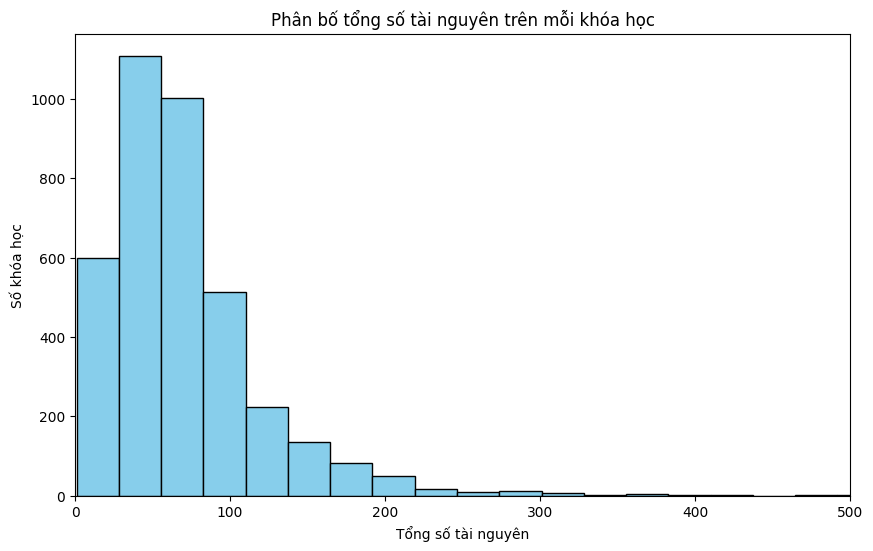

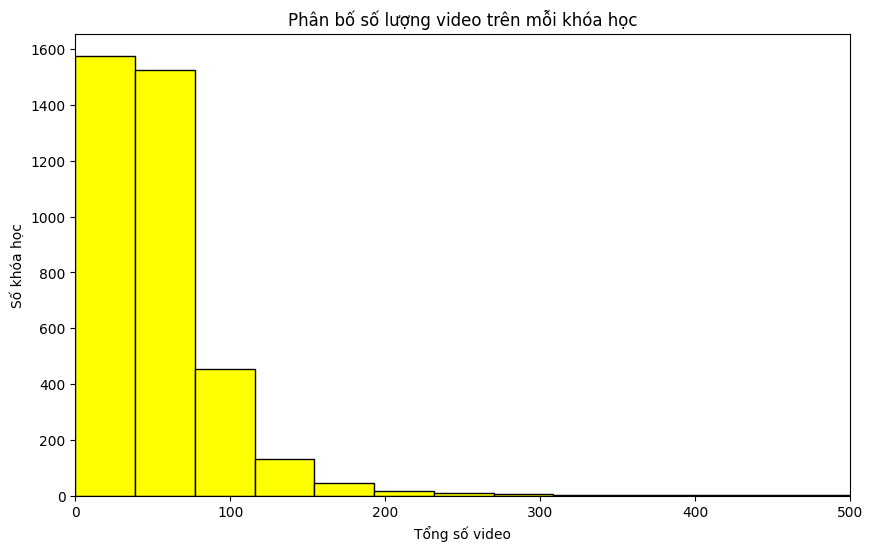

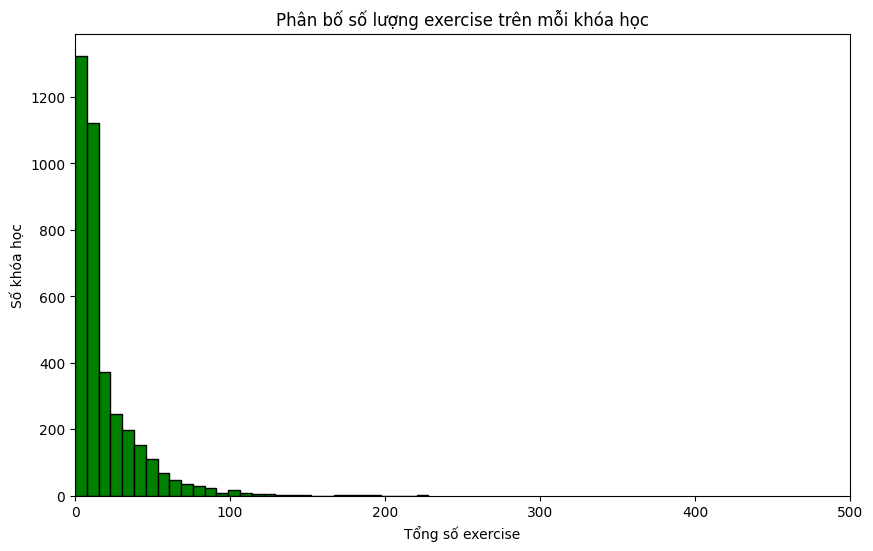

In [84]:
# Vẽ biểu đồ phân bố số lượng tài nguyên của mỗi khóa học. Số tài nguyên là số video_id và ex_id.

plt.figure(figsize=(10, 6))
plt.hist(courses_df['video_counts'] + courses_df['ex_counts'], bins=100, color='skyblue', edgecolor='black')
#Biểu đồ zoom vào từ 0 đến 500
plt.xlim(0, 500)
plt.xlabel('Tổng số tài nguyên')
plt.ylabel('Số khóa học')
plt.title('Phân bố tổng số tài nguyên trên mỗi khóa học')


# Vẽ biểu đồ số tài nguyên dạng video và ex
plt.figure(figsize=(10, 6))
plt.hist(courses_df['video_counts'] , bins=70, color='yellow', edgecolor='black')
#Biểu đồ zoom vào từ 0 đến 500
plt.xlim(0, 500)
plt.xlabel('Tổng số video')
plt.ylabel('Số khóa học')
plt.title('Phân bố số lượng video trên mỗi khóa học')

plt.figure(figsize=(10, 6))
plt.hist(courses_df['ex_counts'], bins=30, color='green', edgecolor='black')
#Biểu đồ zoom vào từ 0 đến 1000
plt.xlim(0, 500)
plt.xlabel('Tổng số exercise')
plt.ylabel('Số khóa học')
plt.title('Phân bố số lượng exercise trên mỗi khóa học')
plt.show()

In [85]:
# Số lượng khóa học không có bất kỳ tài nguyên nào
print(courses_df[(courses_df['video_counts'] == 0) & (courses_df['ex_counts'] == 0)].shape)
# Số lượng khóa học không có bất kỳ video nào
print(courses_df[courses_df['video_counts'] == 0].shape)
# Số lượng khóa học không có bất kỳ exercise nào
print(courses_df[courses_df['ex_counts'] == 0].shape)

(0, 6)
(11, 6)
(577, 6)


In [86]:
# --- IQR cho ex_counts ---
stats_ex = courses_df['ex_counts'].describe()
Q1_ex = stats_ex['25%']
Q3_ex = stats_ex['75%']
IQR_ex = Q3_ex - Q1_ex
lower_ex = Q1_ex - 1.5 * IQR_ex
upper_ex = Q3_ex + 1.5 * IQR_ex

print(f"[Exercise] Q1: {Q1_ex}, Q3: {Q3_ex}, IQR: {IQR_ex}")
print(f"[Exercise] Lower: {lower_ex}, Upper: {upper_ex}")

mask_ex = (courses_df['ex_counts'] >= lower_ex) & (courses_df['ex_counts'] <= upper_ex)

# --- IQR cho video_counts ---
stats_vid = courses_df['video_counts'].describe()
Q1_vid = stats_vid['25%']
Q3_vid = stats_vid['75%']
IQR_vid = Q3_vid - Q1_vid
lower_vid = Q1_vid - 1.5 * IQR_vid
upper_vid = Q3_vid + 1.5 * IQR_vid

print(f"[Video] Q1: {Q1_vid}, Q3: {Q3_vid}, IQR: {IQR_vid}")
print(f"[Video] Lower: {lower_vid}, Upper: {upper_vid}")

mask_vid = (courses_df['video_counts'] >= lower_vid) & (courses_df['video_counts'] <= upper_vid)

# --- OR logic: Giữ lại nếu ít nhất 1 cột hợp lệ ---
courses_df_filtered_resources = courses_df[mask_ex | mask_vid].copy()

print(f"Số lượng khóa học trước khi lọc: {len(courses_df)}")
print(f"Số lượng khóa học sau khi lọc: {len(courses_df_filtered_resources)}")


[Exercise] Q1: 5.0, Q3: 23.0, IQR: 18.0
[Exercise] Lower: -22.0, Upper: 50.0
[Video] Q1: 28.0, Q3: 66.0, IQR: 38.0
[Video] Lower: -29.0, Upper: 123.0
Số lượng khóa học trước khi lọc: 3781
Số lượng khóa học sau khi lọc: 3721


In [87]:
courses_df_filtered_resources


,id,name,field,about,video_counts,ex_counts
0,C_584313,《资治通鉴》导读,"[历史学, 中国语言文学]",通过老师导读，同学们可深入这一经典文本内部，得以纵览千年历史，提升国学素养，体味人生智慧。,76,15
1,C_584329,微积分——极限理论与一元函数,"[应用经济学, 数学, 物理学, 理论经济学]",本课程是理工科的一门数学基础课，系统、全面地介绍了一元函数微积分学。课程既保持了数学的严谨和...,133,37
2,C_584381,新闻摄影,"[艺术学, 新闻传播学]",掌握基本的摄影技能，了解图片新闻的工作方式，训练对生活的观察和热爱，发展对图像的审美和批评能...,120,7
3,C_597208,数据挖掘：理论与算法,[计算机科学与技术],最有趣的理论+最有用的算法=不得不学的数据科学。,68,57
4,C_597225,大学计算机,[],大学计算机课程将以计算思维为导向，以计算机原理、概念为基础，以新技术新方法为牵引，以创新思维...,128,37
...,...,...,...,...,...,...
3775,C_2338005,（疾风计划）算法设计与分析,[],疾风计划2021【首期限额招募】进行中\n名校名师丨专属助教丨专业认证丨系统全面丨修炼内功丨...,62,12
3776,C_2338076,（疾风计划）软件工程,[],疾风计划2021【首期限额招募】进行中\n名校名师丨专属助教丨专业认证丨系统全面丨修炼内功丨...,83,20
3777,C_2341259,（疾风计划）面向对象程序设计（C++）,[],疾风计划2021【首期限额招募】进行中\n名校名师丨专属助教丨专业认证丨系统全面丨修炼内功丨...,70,6
3779,C_1945689,机器学习训练营,[],清华张敏老师带你12周掌握机器学习！8大经典算法 +7大实训 + 直播点评 + 博士助教+云...,50,26


# Thêm xử lý School.json và teacher.json

In [88]:
# Đọc dữ liệu school.json và teacher.json
schools_df = pd.read_json(entitiesPath+'/school.json', lines=True)
teachers_df = pd.read_json(entitiesPath+'/teacher.json', lines=True)

In [89]:
print(teachers_df.info())
teachers_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17018 entries, 0 to 17017
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         17018 non-null  object
 1   name       17018 non-null  object
 2   name_en    9525 non-null   object
 3   about      17018 non-null  object
 4   job_title  17018 non-null  object
 5   org_name   17018 non-null  object
dtypes: object(6)
memory usage: 797.8+ KB
None


(17018, 6)

In [90]:
print(schools_df.info())
schools_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       429 non-null    object
 1   name     429 non-null    object
 2   name_en  429 non-null    object
 3   sign     429 non-null    object
 4   about    429 non-null    object
 5   motto    429 non-null    object
dtypes: object(6)
memory usage: 20.2+ KB
None


(429, 6)

In [91]:
schools_df

,id,name,name_en,sign,about,motto
0,S_1,清华大学,Tsinghua University,thu,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"自强不息,厚德载物"
1,S_2,北京大学,Peking University,PKU,北京大学（Peking University），简称“北大”，是中华人民共和国教育部直属的全...,博学、审问、慎思、明辨
2,S_3,武汉大学,Wuhan University,whu,武汉大学（Wuhan University）简称“武大”，是中华人民共和国教育部直属的综合性...,自强 弘毅 求是 拓新
3,S_4,苏州大学,Soochow University,suda,苏州大学（Soochow University），坐落于历史文化名城苏州，是教育部与江苏省人...,养天地正气，法古今完人
4,S_5,四川大学,Sichuan University,scu,四川大学（Sichuan University），简称“川大”，坐落于四川省会成都，是教育部...,
...,...,...,...,...,...,...
424,S_1402,高雄医学大学,Kaohsiung Medical University,Kaohsiung Medical University,高雄医学大学（Kaohsiung Medical University）源自1954年创校的...,
425,S_1405,黑龙江农垦职业学院,Heilongjiang Agricultural ReclamationVocationa...,nkzy,黑龙江农垦职业学院（Heilongjiang Agricultural Reclamatio...,
426,S_1448,江西财经大学,Jiangxi University of Finance And Economics,jxufe,江西财经大学（Jiangxi University of Finance and Econo...,
427,S_1453,贵州交通职业技术学院,GuiZhou Communications Polytechnic,gzjtzy,贵州交通职业技术学院是一所以交通为特色的理工类高职院校。创办于1958年，走过国家“示范校”...,知行合一 德技双馨


In [92]:
teachers_df.head()
# in số lương teacher_id duy nhất
print(teachers_df['id'].nunique())
# số lượng course_id duy nhất
print(courses_df_filtered_resources['id'].nunique())

17018
3721


In [93]:
print(schools_df.isna().sum())
print(teachers_df.isna().sum())

id         0
name       0
name_en    0
sign       0
about      0
motto      0
dtype: int64
id              0
name            0
name_en      7493
about           0
job_title       0
org_name        0
dtype: int64


In [94]:
# Doc du lieu file relations: school-course.txt , courses-teacher.txt
school_course_df = pd.read_csv(relationsPath+'/course-school.txt', sep='\t', header=None, names=['course_id', 'school_id'])
courses_teacher_df = pd.read_csv(relationsPath+'/course-teacher.txt', sep='\t', header=None, names=['course_id', 'teacher_id'])
school_course_df.head()

,course_id,school_id
0,C_375629,S_1
1,C_375775,S_1
2,C_375778,S_1
3,C_584313,S_1
4,C_584329,S_1


In [95]:
print(courses_teacher_df.shape)
courses_teacher_df.head()

(97192, 2)


,course_id,teacher_id
0,C_323899,T_5092
1,C_323899,T_5092
2,C_324384,T_6164
3,C_324384,T_6472
4,C_324384,T_6471


In [96]:
# Kiểm tra tính duy nhất của course_id và school_id
print(school_course_df.duplicated(subset=['course_id', 'school_id']).sum())
# Kiểm tra tính duy nhất của course_id và teacher_id
print(courses_teacher_df.duplicated(subset=['course_id', 'teacher_id']).sum())

0
51186


In [97]:
# In ra những dòng teacher trùng lấp
print(courses_teacher_df[courses_teacher_df.duplicated(subset=['course_id', 'teacher_id'], keep=False)])
# Giữ lại duy nhất 1 dòng của các dữ liệu trùng
courses_teacher_df = courses_teacher_df.drop_duplicates(subset=['course_id', 'teacher_id'], keep='first')
courses_teacher_df.shape

       course_id teacher_id
0       C_323899     T_5092
1       C_323899     T_5092
2       C_324384     T_6164
3       C_324384     T_6472
4       C_324384     T_6471
...          ...        ...
97187  C_2359387    T_16656
97188  C_2359387    T_16657
97189  C_2359387    T_16655
97190  C_2359388    T_17107
97191  C_2359388    T_17107

[67795 rows x 2 columns]


(46006, 2)

In [98]:
# Merge school_df voi school_course_df
school_course_df = school_course_df.merge(schools_df, left_on='school_id', right_on='id', how='inner')
# Merge teacher_df voi courses_teacher_df
courses_teacher_df = courses_teacher_df.merge(teachers_df, left_on='teacher_id', right_on='id', how='inner')
courses_teacher_df.head()
#

,course_id,teacher_id,id,name,name_en,about,job_title,org_name
0,C_323899,T_5092,T_5092,邓铭,Ming Deng,邓铭，作为云南大学经济学院外贸系教师，同时也是国际经济与贸易、国际商务专业硕士的研究生导师。...,副教授,云南大学
1,C_324384,T_6164,T_6164,孔春丽,Chunli Kong,经济学博士，云南大学经济学院会计系任教。先后在核心学术期刊上发表论文十余篇；立项建设《会计学...,讲师,云南大学
2,C_324384,T_6472,T_6472,马映涛,None,云南大学专业教师，职称讲师。研究方向：财务会计；政府与非营利组织会计；主讲课程：会计学；财务...,讲师,云南大学
3,C_324384,T_6471,T_6471,张雅涵,None,云南大学经济学院（会计学院）会计系讲师，硕士研究生学历，现担任《会计学》、《会计模拟实践》等...,讲师,云南大学
4,C_324384,T_6473,T_6473,赖珺,None,云南大学经济学院讲师，硕士生导师。研究方向：财务会计，管理会计。在东京农工大学取得博士学位，...,讲师,云南大学


In [99]:
school_course_df.head()

,course_id,school_id,id,name,name_en,sign,about,motto
0,C_375629,S_1,S_1,清华大学,Tsinghua University,thu,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"自强不息,厚德载物"
1,C_375775,S_1,S_1,清华大学,Tsinghua University,thu,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"自强不息,厚德载物"
2,C_375778,S_1,S_1,清华大学,Tsinghua University,thu,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"自强不息,厚德载物"
3,C_584313,S_1,S_1,清华大学,Tsinghua University,thu,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"自强不息,厚德载物"
4,C_584329,S_1,S_1,清华大学,Tsinghua University,thu,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"自强不息,厚德载物"


In [100]:
courses_teacher_df.drop(columns = {'id','name_en'})
school_course_df.drop(columns = {'id','name_en','sign'})
# Rename 2 cot about
school_course_df.rename(columns={'about':'school_about'}, inplace=True)
courses_teacher_df.rename(columns={'about':'teacher_about'}, inplace=True)
# Rename 2 cot name
school_course_df.rename(columns={'name':'school_name'}, inplace=True)
courses_teacher_df.rename(columns={'name':'teacher_name'}, inplace=True)
# Rename cot id của course_df_filtered_resources
courses_df_filtered_resources.rename(columns={'id':'course_id'}, inplace=True)

In [101]:
# Merge 2 df tren voi course_df
courses_df_filtered_resources = courses_df_filtered_resources.merge(school_course_df[['course_id', 'school_id', 'school_name','school_about']], on='course_id', how='left')
courses_df_filtered_resources = courses_df_filtered_resources.merge(courses_teacher_df[['course_id', 'teacher_id','teacher_name','teacher_about']], on='course_id', how='left')
courses_df_filtered_resources.head()

,course_id,name,field,about,video_counts,ex_counts,school_id,school_name,school_about,teacher_id,teacher_name,teacher_about
0,C_584313,《资治通鉴》导读,"[历史学, 中国语言文学]",通过老师导读，同学们可深入这一经典文本内部，得以纵览千年历史，提升国学素养，体味人生智慧。,76,15,S_1,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,T_20,张国刚,张国刚，男，1956年生，安徽安庆人，历史学博士，清华大学人文学院历史系教授、博士生导师。从...
1,C_584329,微积分——极限理论与一元函数,"[应用经济学, 数学, 物理学, 理论经济学]",本课程是理工科的一门数学基础课，系统、全面地介绍了一元函数微积分学。课程既保持了数学的严谨和...,133,37,S_1,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,T_21,扈志明,1987年毕业于北京大学数学系，获学士学位，1993年毕业于中国科学院数学研究所，获博士学位...
2,C_584329,微积分——极限理论与一元函数,"[应用经济学, 数学, 物理学, 理论经济学]",本课程是理工科的一门数学基础课，系统、全面地介绍了一元函数微积分学。课程既保持了数学的严谨和...,133,37,S_1,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,T_22,章纪民,章纪民，男，清华大学数学科学系 副教授。分别于1985年、1988年和1991年在清华大学应...
3,C_584381,新闻摄影,"[艺术学, 新闻传播学]",掌握基本的摄影技能，了解图片新闻的工作方式，训练对生活的观察和热爱，发展对图像的审美和批评能...,120,7,S_1,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,T_23,梁君健,清华大学新闻与传播学院副教授，美国南卡罗来纳大学人类学系访问学者。讲授新闻摄影、影视制作等课...
4,C_597208,数据挖掘：理论与算法,[计算机科学与技术],最有趣的理论+最有用的算法=不得不学的数据科学。,68,57,S_1,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,T_28,袁博,澳大利亚昆士兰大学计算机科学博士，清华大学深圳国际研究生院培养处副处长，博士生导师，国家精品...


In [102]:
# Group_by cot id tạo mảng teacher_id và teacher_about
courses_df_filtered_resources_school_teacher = courses_df_filtered_resources.groupby('course_id').agg({
    'name': 'first',
    'field': 'first',
    'about': 'first',
    'video_counts': 'first',
    'ex_counts': 'first',
    'school_id': 'first',
    'school_name':'first',
    'school_about': 'first',
    'teacher_name': lambda x: list(x.dropna()),
    'teacher_id': lambda x: list(x.dropna()),
    'teacher_about': lambda x: list(x.dropna())
}).reset_index()



In [103]:
courses_df_filtered_resources_school_teacher.head()

,course_id,name,field,about,video_counts,ex_counts,school_id,school_name,school_about,teacher_name,teacher_id,teacher_about
0,C_1017355,中医英语入门,[],中医药文化——中华文化的瑰宝和精髓，需要我们每一位国人传承和弘扬！如何开始用英语讲中医故事？...,19,19,S_33,广州中医药大学,广州中医药大学（Guangzhou University of Chinese Medici...,"[苏红, 刘帅帅, 张小虎, 何柳, 孟宪友]","[T_7970, T_7971, T_5826, T_7978, T_7979]",[英语语言学硕士；现任广州中医药大学外国语学院院长；广州中医药大学中医翻译与国际传播研究中心...
1,C_1017419,智慧政府漫谈,[],本课程结合具体的交通拥堵、雾霾、看病难、食品安全等案例，漫谈智慧政府，让智慧政府变得不再抽象。,17,9,S_52,中南民族大学,中南民族大学（South-Central Minzu University），简称中南民大（...,"[胡新丽, 吴开松, 彭庆军, 方付建, 李世颉, 吴艳艳, 王文友, 王志华]","[T_7849, T_16199, T_16200, T_16201, T_16202, T...","[管理学博士，副教授，行政管理系主任,学院外事秘书。2011年8月获国家留学基金委资助赴美国..."
2,C_1025064,思想政治教育学原理,[],亲爱的同学你好！你想知道思想政治教育是怎样产生和发展的吗？ 思想与行为是如何相互转化的？在思...,89,14,S_13,中南大学,中南大学（Central South University），位于湖南省长沙市，是中华人民共...,"[刘伟, 刘勇为, 林洁, 郭鹏飞, 贺才乐]","[T_3915, T_3911, T_5426, T_5427, T_5429]",[刘伟，男，1968年出生于湖南省衡南县。1990年毕业于湘潭大学，获思想政治教育专业法学学...
3,C_1025076,轮滑高级教程,[],体验轮滑运动快乐真谛在于，对滑行速度提升的不断追求，对炫酷新颖的花样动作的不断尝试，以及交替...,43,4,S_72,东北大学,"东北大学（Northeastern University, NEU），坐落于辽宁省沈阳市，是...",[厉中山],[T_5394],[东北大学轮滑项目专任教师，体育教育训练学硕士，轮滑全国冠军，轮滑项目国家级运动健将，速度轮...
4,C_1025079,科学健身法-缠丝健身功,[],缠丝功是解决人类“进化病”的中国方案。面对肩颈僵硬，腰酸背疼，头昏脑涨，北京...,34,5,S_97,北京体育大学,北京体育大学（Beijing Sport University），简称北体大，由国家体育总局...,[武冬],[T_7939],[教授，教育学博士，博导，北京市教学名师，北京体育大学中国武术学院武术套路教研室副主任，国际...


In [104]:
# Drop school_id và teacher_id
courses_df_filtered_resources_school_teacher.drop(columns = {'school_id','teacher_id'})

,course_id,name,field,about,video_counts,ex_counts,school_name,school_about,teacher_name,teacher_about
0,C_1017355,中医英语入门,[],中医药文化——中华文化的瑰宝和精髓，需要我们每一位国人传承和弘扬！如何开始用英语讲中医故事？...,19,19,广州中医药大学,广州中医药大学（Guangzhou University of Chinese Medici...,"[苏红, 刘帅帅, 张小虎, 何柳, 孟宪友]",[英语语言学硕士；现任广州中医药大学外国语学院院长；广州中医药大学中医翻译与国际传播研究中心...
1,C_1017419,智慧政府漫谈,[],本课程结合具体的交通拥堵、雾霾、看病难、食品安全等案例，漫谈智慧政府，让智慧政府变得不再抽象。,17,9,中南民族大学,中南民族大学（South-Central Minzu University），简称中南民大（...,"[胡新丽, 吴开松, 彭庆军, 方付建, 李世颉, 吴艳艳, 王文友, 王志华]","[管理学博士，副教授，行政管理系主任,学院外事秘书。2011年8月获国家留学基金委资助赴美国..."
2,C_1025064,思想政治教育学原理,[],亲爱的同学你好！你想知道思想政治教育是怎样产生和发展的吗？ 思想与行为是如何相互转化的？在思...,89,14,中南大学,中南大学（Central South University），位于湖南省长沙市，是中华人民共...,"[刘伟, 刘勇为, 林洁, 郭鹏飞, 贺才乐]",[刘伟，男，1968年出生于湖南省衡南县。1990年毕业于湘潭大学，获思想政治教育专业法学学...
3,C_1025076,轮滑高级教程,[],体验轮滑运动快乐真谛在于，对滑行速度提升的不断追求，对炫酷新颖的花样动作的不断尝试，以及交替...,43,4,东北大学,"东北大学（Northeastern University, NEU），坐落于辽宁省沈阳市，是...",[厉中山],[东北大学轮滑项目专任教师，体育教育训练学硕士，轮滑全国冠军，轮滑项目国家级运动健将，速度轮...
4,C_1025079,科学健身法-缠丝健身功,[],缠丝功是解决人类“进化病”的中国方案。面对肩颈僵硬，腰酸背疼，头昏脑涨，北京...,34,5,北京体育大学,北京体育大学（Beijing Sport University），简称北体大，由国家体育总局...,[武冬],[教授，教育学博士，博导，北京市教学名师，北京体育大学中国武术学院武术套路教研室副主任，国际...
...,...,...,...,...,...,...,...,...,...,...
3716,C_955163,学做小程序——实战篇：树洞小程序,[],本课程是由清华大学软件学院和乐享其约共同制作的微信小程序学习教程，由“乐享其约”资深项目经理...,101,7,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"[刘强, 施建锋, 伊甸, 小程序慕课讲师]",[刘强，清华大学软件学院副教授，研究生导师，担任教育部软件工程专业教学指导分委员会委员，国家...
3717,C_956128,肝硬化门脉高压热点问题解读,[],门脉高压热点问题解读,27,7,山东大学,山东大学（Shandong University），由中华人民共和国教育部直属，中央直管副部...,"[高艳景, 程宝泉, 周涛]",[高艳景，主任医师，教授。主持山东省自然科学基金、济南市科技发展计划（高校自主创新）、山东省...
3718,C_956129,游戏与电竞概论,[],游戏产业从设计开发、运营服务到电子竞技都已经成为当下热门的职业。本课深入探讨游戏电竞过去与未...,73,23,广州科技贸易职业学院,广州科技贸易职业学院，位于广东省广州市，是经广东省政府批准、国家教育部备案的广州市属公办全日...,"[邬厚民, 陈赞蔚, 梁斌, 朱恺文]",[邬厚民，副教授，广州科技贸易职业学院信息工程学院院长，广东省高校优秀青年教师，广东省“千百...
3719,C_956130,多媒体技术及应用,[],本课程主要学习多媒体技术的基本概念，学会使用多媒体硬件设备和多媒体软件环境，从应用的角度出发...,71,15,华南理工大学,华南理工大学（South China University of Technology），简...,"[郭芬, 林育蓓, 陆芳]",[郭芬，博士，华南理工大学软件学院高级实验师，主要研究领域为云计算应用技术及数据库技术。 从...


In [105]:
print(courses_df_filtered_resources_school_teacher.isna().sum())

course_id          0
name               0
field              0
about              2
video_counts       0
ex_counts          0
school_id        200
school_name      200
school_about     200
teacher_name       0
teacher_id         0
teacher_about      0
dtype: int64


In [106]:
#  Loai bo khóa học không có thông tin school và mảng teacher_name có độ dài bằng 0
courses_df_filtered_resources_school_teacher = courses_df_filtered_resources_school_teacher[
    ~(
        courses_df_filtered_resources_school_teacher['school_name'].isna() &
        (courses_df_filtered_resources_school_teacher['teacher_name'].apply(len) == 0)
    )
].copy()

print(courses_df_filtered_resources_school_teacher.shape)

(3675, 12)


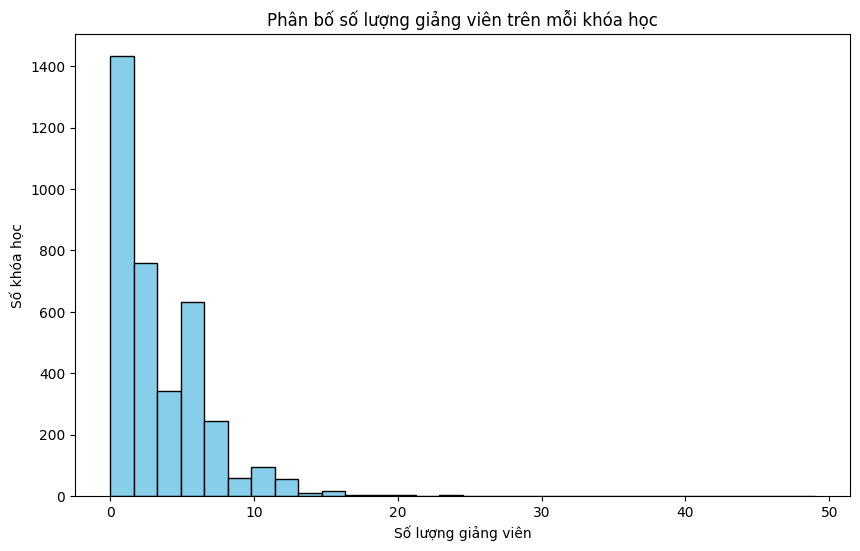

In [107]:
# Vẽ biểu đồ biểu diễn phân bố số lượng giảng viên của từng khóa học
plt.figure(figsize=(10, 6))
plt.hist(courses_df_filtered_resources_school_teacher['teacher_id'].apply(len), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Số lượng giảng viên')
plt.ylabel('Số khóa học')
plt.title('Phân bố số lượng giảng viên trên mỗi khóa học')
plt.show()

# Giảm số lượng course

Vẽ biểu đồ số lượng đăng ký của từng khóa học để lựa chọn ngưỡng làm gọn dữ liệu

In [108]:
# Đọc dữ liệu user_data.parquet sau khi sử lý
user_df = pd.concat(read_jsonl_in_batches(entitiesPath+'/user.json'), ignore_index=True)
# Dựa vào mảng course_order của cột dữ liệu course_order để tổng hợp số lượng học viên của từng khóa học
course_order_explode = user_df.explode('course_order')
course_counts = course_order_explode['course_order'].value_counts()
course_counts

[Done] Đọc xong 3330294 dòng hợp lệ, 0 dòng lỗi.


/tmp/ipython-input-1777297450.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  user_df = pd.concat(read_jsonl_in_batches(entitiesPath+'/user.json'), ignore_index=True)


,count
course_order,
936971,231674
696994,181697
676932,125789
697791,96210
883345,78374
...,...
681805,1
681810,1
681813,1


In [109]:
stats= course_counts.describe()
Q1 = stats['25%']
Q3 = stats['75%']
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Giá trị Q1: {Q1}')
print(f'Giá trị Q3: {Q3}')
print(f'Giá trị IQR: {IQR}')

Giá trị Q1: 7.0
Giá trị Q3: 2171.0
Giá trị IQR: 2164.0


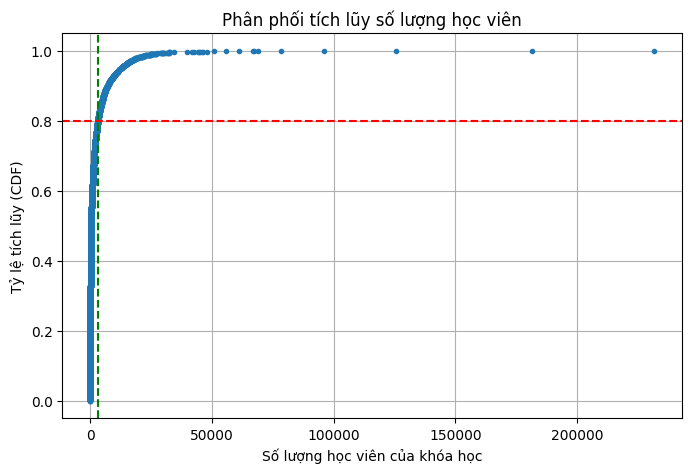

In [110]:
# Vẽ biểu đồ biểu thị số lượng học viên của khóa học
# Sắp xếp tăng dần
sorted_counts = np.sort(course_counts)

# Tính CDF
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
threshold = 0.8
x_threshold = sorted_counts[np.searchsorted(cdf, threshold)]
# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.plot(sorted_counts, cdf, marker='.', linestyle='none')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'{threshold*100:.0f}% khóa học')
plt.axvline(x=x_threshold, color='g', linestyle='--', label=f'~{x_threshold} học viên')
plt.xlabel('Số lượng học viên của khóa học')
plt.ylabel('Tỷ lệ tích lũy (CDF)')
plt.title('Phân phối tích lũy số lượng học viên')
plt.grid(True)
plt.show()

In [111]:
print(course_counts.shape)
# Lọc dữ liệu course_df
course_counts_filtered = course_counts.copy()
print(course_counts_filtered.shape)

(4701,)
(4701,)


In [112]:
# Thêm ký tự C_ vào course_id
course_counts_filtered.index = 'C_' + course_counts_filtered.index.astype(str)

In [113]:
# Sử dụng course_id của course_counts để lọc lại course_df
courses_df_filtered = courses_df_filtered_resources_school_teacher[courses_df_filtered_resources_school_teacher['course_id'].isin(course_counts_filtered.index)]
print(courses_df_filtered.shape)

(3675, 12)


In [114]:
resource_df_video = resource_df_video[resource_df_video ['id'].isin(courses_df_filtered['course_id'])]
print(resource_df_video .shape)
resource_df_exercise = resource_df_exercise[resource_df_exercise ['id'].isin(courses_df_filtered['course_id'])]
print(resource_df_exercise.shape)

(3665, 6)
(3124, 6)


In [115]:
courses_df_filtered = courses_df_filtered.drop(columns ={'school_id','teacher_id'})

In [117]:
# Luu tru dataframe course_df_filtered, course_resource_video, course_resource_exercise thanh dang parquet
courses_df_filtered.to_parquet('/content/drive/MyDrive/MOOCCubeX/EDA2/entities/courses_df_filtered.parquet')
resource_df_video.to_parquet('/content/drive/MyDrive/MOOCCubeX/EDA2/relations/resource_df_video.parquet')
resource_df_exercise.to_parquet('/content/drive/MyDrive/MOOCCubeX/EDA2/relations/resource_df_exercise.parquet')
#

In [119]:
# Mo file kiem tra
courses_df_filtered = pd.read_parquet(basePath+'EDA2/entities/courses_data.parquet')
courses_df_filtered.head()
#

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MOOCCubeX/Dataset/EDA2/entities/courses_data.parquet'

In [118]:
courses_df_filtered

,course_id,name,field,about,video_counts,ex_counts,school_name,school_about,teacher_name,teacher_about
0,C_1017355,中医英语入门,[],中医药文化——中华文化的瑰宝和精髓，需要我们每一位国人传承和弘扬！如何开始用英语讲中医故事？...,19,19,广州中医药大学,广州中医药大学（Guangzhou University of Chinese Medici...,"[苏红, 刘帅帅, 张小虎, 何柳, 孟宪友]",[英语语言学硕士；现任广州中医药大学外国语学院院长；广州中医药大学中医翻译与国际传播研究中心...
1,C_1017419,智慧政府漫谈,[],本课程结合具体的交通拥堵、雾霾、看病难、食品安全等案例，漫谈智慧政府，让智慧政府变得不再抽象。,17,9,中南民族大学,中南民族大学（South-Central Minzu University），简称中南民大（...,"[胡新丽, 吴开松, 彭庆军, 方付建, 李世颉, 吴艳艳, 王文友, 王志华]","[管理学博士，副教授，行政管理系主任,学院外事秘书。2011年8月获国家留学基金委资助赴美国..."
2,C_1025064,思想政治教育学原理,[],亲爱的同学你好！你想知道思想政治教育是怎样产生和发展的吗？ 思想与行为是如何相互转化的？在思...,89,14,中南大学,中南大学（Central South University），位于湖南省长沙市，是中华人民共...,"[刘伟, 刘勇为, 林洁, 郭鹏飞, 贺才乐]",[刘伟，男，1968年出生于湖南省衡南县。1990年毕业于湘潭大学，获思想政治教育专业法学学...
3,C_1025076,轮滑高级教程,[],体验轮滑运动快乐真谛在于，对滑行速度提升的不断追求，对炫酷新颖的花样动作的不断尝试，以及交替...,43,4,东北大学,"东北大学（Northeastern University, NEU），坐落于辽宁省沈阳市，是...",[厉中山],[东北大学轮滑项目专任教师，体育教育训练学硕士，轮滑全国冠军，轮滑项目国家级运动健将，速度轮...
4,C_1025079,科学健身法-缠丝健身功,[],缠丝功是解决人类“进化病”的中国方案。面对肩颈僵硬，腰酸背疼，头昏脑涨，北京...,34,5,北京体育大学,北京体育大学（Beijing Sport University），简称北体大，由国家体育总局...,[武冬],[教授，教育学博士，博导，北京市教学名师，北京体育大学中国武术学院武术套路教研室副主任，国际...
...,...,...,...,...,...,...,...,...,...,...
3716,C_955163,学做小程序——实战篇：树洞小程序,[],本课程是由清华大学软件学院和乐享其约共同制作的微信小程序学习教程，由“乐享其约”资深项目经理...,101,7,清华大学,简称“清华”，由中华人民共和国教育部直属，中央直管副部级建制，位列“211工程”、“985工...,"[刘强, 施建锋, 伊甸, 小程序慕课讲师]",[刘强，清华大学软件学院副教授，研究生导师，担任教育部软件工程专业教学指导分委员会委员，国家...
3717,C_956128,肝硬化门脉高压热点问题解读,[],门脉高压热点问题解读,27,7,山东大学,山东大学（Shandong University），由中华人民共和国教育部直属，中央直管副部...,"[高艳景, 程宝泉, 周涛]",[高艳景，主任医师，教授。主持山东省自然科学基金、济南市科技发展计划（高校自主创新）、山东省...
3718,C_956129,游戏与电竞概论,[],游戏产业从设计开发、运营服务到电子竞技都已经成为当下热门的职业。本课深入探讨游戏电竞过去与未...,73,23,广州科技贸易职业学院,广州科技贸易职业学院，位于广东省广州市，是经广东省政府批准、国家教育部备案的广州市属公办全日...,"[邬厚民, 陈赞蔚, 梁斌, 朱恺文]",[邬厚民，副教授，广州科技贸易职业学院信息工程学院院长，广东省高校优秀青年教师，广东省“千百...
3719,C_956130,多媒体技术及应用,[],本课程主要学习多媒体技术的基本概念，学会使用多媒体硬件设备和多媒体软件环境，从应用的角度出发...,71,15,华南理工大学,华南理工大学（South China University of Technology），简...,"[郭芬, 林育蓓, 陆芳]",[郭芬，博士，华南理工大学软件学院高级实验师，主要研究领域为云计算应用技术及数据库技术。 从...
